# M_04 — Réassemblage du graphe fusionné

M_04 — Réassemblage du graphe fusionné (source-agnostique).

Entrée (toutes dans MATCHING_DIR, sorties réelles de M_01/M_02/M_03) :
   nodes.csv          (M_01)  source, node_id, x, y
   edges.gpkg         (M_01)  source, node_start, node_end, commune_a, commune_b, geometry
                              (ARCS PARTAGÉS uniquement — cf. limite § réassemblage)
   match_nodes.csv    (M_02)  source_a, node_a, x_a, y_a, source_b, node_b, x_b, y_b, distance_m
   match_edges.csv    (M_02)  source_a, source_b, edge_idx_a, edge_idx_b, communes_a, communes_b, hausdorff_m
   nodes_fused.gpkg   (M_03)  cluster, zone, n_sources, x_fusion, y_fusion, geometry

Sortie : fusion.gpkg au format TOPOLOGIQUE des sources (couches noeuds + arcs ; chaque
         frontière partagée stockée UNE seule fois, avec comm_a/comm_b). Directement
         convertible OSM (arcs→ways, comm_a/comm_b→relations, noeuds→nodes).
         PAS de polygonisation en sortie : elle dupliquerait les frontières partagées
         et détruirait la topologie.

Principe : AUCUNE source n'est traitée par son nom. La fiabilité est APPRISE (truth discovery).

Garantie visée : topologie de qualité « partition propre » — CHAQUE frontière existe UNE
seule fois dans la sortie. L'identité d'une frontière est sa PAIRE DE COMMUNES (même
critère que le filtre sémantique de M_02) : un arc mono-source dont la paire est déjà
représentée par une autre provenance est un doublon, écarté quelle que soit sa distance
(les fragments divergents type rivière sont donc éliminés). Les fragments d'une même
source pour une même paire sont des compléments, pas des doublons : gardés.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from collections import defaultdict, Counter
from shapely.geometry import LineString, Point
from shapely.ops import polygonize, unary_union

## 0. CONFIGURATION

In [2]:
MATCHING_DIR = r'C:/Users/rocrom/Resolving-Conflicts-in-Heterogeneous-Data--CRH_Framework/final'
CRS = 2154

TARGET_SPACING_M = 5.0         # un point tous les ~5 m (N dérivé de la donnée)
N_MIN, N_MAX     = 8, 400
W_MAX_ITER, W_TOL, EPS = 30, 1e-4, 1e-9
SNAP_BLEND_PTS = 3
NODE_MERGE_TOL = 30.0   # extrémités d'arcs à moins de 30 m = même nœud (raccord de bord)

## 1. CHARGEMENT (branché sur les vraies sorties M_01/M_02/M_03)

In [3]:
def load_inputs():
    nodes_df    = pd.read_csv(f'{MATCHING_DIR}/nodes.csv')
    match_nodes = pd.read_csv(f'{MATCHING_DIR}/match_nodes.csv')
    match_edges = pd.read_csv(f'{MATCHING_DIR}/match_edges.csv')
    nodes_fused = gpd.read_file(f'{MATCHING_DIR}/nodes_fused.gpkg')
    edges_gdf   = gpd.read_file(f'{MATCHING_DIR}/edges.gpkg')

    SOURCES = sorted(nodes_df['source'].unique())

    # ⚠ Indexation IDENTIQUE à M_02 : edge_idx_a/edge_idx_b de match_edges pointent
    # dans edges[src] = tranche par source, reset_index. À reproduire à l'identique.
    edges = {s: edges_gdf[edges_gdf.source == s].reset_index(drop=True) for s in SOURCES}

    # ⚠ LIMITE (à faire évoluer) : edges.gpkg ne contient que les arcs PARTAGÉS. Le
    # bord de la zone (arcs non partagés) manque → les communes de pourtour ne se
    # refermeront pas. Étape suivante : réinjecter ces arcs depuis la couche topo.
    return SOURCES, edges, nodes_df, match_nodes, match_edges, nodes_fused

## 2. NŒUDS FUSIONNÉS — on RECHARGE M_03 (positions autoritaires), sans recalcul

In [4]:
def build_fused_lookup(match_nodes, nodes_df, nodes_fused):
    """
    Fournit, pour toute (source, node_id) :
      node_pos(src, nid) -> position fusionnée (M_03) si le nœud est dans un cluster
                            apparié, sinon sa position d'origine (nœud singleton).
      node_key(src, nid) -> clé de cluster (pour orienter/canoniser).

    Les clusters sont reconstruits EXACTEMENT comme M_03 (même union-find, mêmes clés
    J0, J1, …) pour pouvoir joindre aux positions fusionnées de nodes_fused.gpkg.
    """
    orig = {(r['source'], int(r['node_id'])): np.array([r['x'], r['y']], float)
            for _, r in nodes_df.iterrows()}

    # --- union-find répliqué à l'identique de M_03 (clés J{i} alignées) ---
    parent, pos = {}, {}
    def find(k):
        parent.setdefault(k, k)
        while parent[k] != k:
            parent[k] = parent[parent[k]]; k = parent[k]
        return k
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for _, r in match_nodes.iterrows():
        a = (r['source_a'], int(r['node_a'])); b = (r['source_b'], int(r['node_b']))
        pos[a] = np.array([r['x_a'], r['y_a']], float)
        pos[b] = np.array([r['x_b'], r['y_b']], float)
        union(a, b)

    clusters = defaultdict(dict)
    for kn in pos:
        clusters[find(kn)][kn[0]] = pos[kn]
    root2key = {root: f'J{i}' for i, root in enumerate(clusters.keys())}
    node2key = {kn: root2key[find(kn)] for kn in pos}

    fused_by_key = {r['cluster']: np.array([r['x_fusion'], r['y_fusion']], float)
                    for _, r in nodes_fused.iterrows()}

    # contrôle de cohérence (le nb de clusters doit coller à nodes_fused)
    if len(root2key) != len(fused_by_key):
        print(f'⚠  clusters reconstruits ({len(root2key)}) ≠ nodes_fused '
              f'({len(fused_by_key)}) — vérifier que match_nodes est identique à M_03.')

    def node_pos(src, nid):
        k = node2key.get((src, int(nid)))
        if k is not None and k in fused_by_key:
            return fused_by_key[k]
        return orig[(src, int(nid))]            # nœud non apparié : position d'origine

    def node_key(src, nid):
        return node2key.get((src, int(nid)), f'{src}:{int(nid)}')

    return node_pos, node_key

## 3. GROUPES D'ARCS HOMOLOGUES (union-find sur match_edges)

In [5]:
class UnionFind:
    def __init__(self): self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]; x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.parent[rb] = ra
    def groups(self):
        out = {}
        for x in list(self.parent):
            out.setdefault(self.find(x), []).append(x)
        return list(out.values())


def build_arc_groups(match_edges, edges):
    """Groupe les arcs homologues. Arc sans appariement -> groupe singleton (mono-source)."""
    uf = UnionFind()
    for src, g in edges.items():
        for i in g.index:
            uf.find((src, int(i)))
    for _, m in match_edges.iterrows():
        uf.union((m['source_a'], int(m['edge_idx_a'])),
                 (m['source_b'], int(m['edge_idx_b'])))
    return uf.groups()

## 4. PRIMITIVES GÉOMÉTRIQUES (label-free)

In [6]:
def resample(coords, n):
    """Rééchantillonne à n points, abscisse curviligne normalisée."""
    P = np.asarray(coords, float)
    seg = np.sqrt(((P[1:] - P[:-1]) ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seg)])
    if s[-1] == 0:
        return np.repeat(P[:1], n, axis=0)
    t = s / s[-1]; tt = np.linspace(0.0, 1.0, n)
    return np.column_stack([np.interp(tt, t, P[:, 0]), np.interp(tt, t, P[:, 1])])


def orient_to(coords, start_xy):
    """Oriente coords pour que son 1er point soit le plus proche de start_xy."""
    P = np.asarray(coords, float)
    return P[::-1] if np.hypot(*(P[-1] - start_xy)) < np.hypot(*(P[0] - start_xy)) else P


def choose_n(versions):
    """N dérivé de la donnée : longueur médiane / pas cible, borné."""
    L = float(np.median([LineString(v).length for v in versions]))
    return int(np.clip(round(L / TARGET_SPACING_M) + 1, N_MIN, N_MAX))


def weighted_consensus(stack, w):
    """Moyenne pondérée par point. stack (K,N,2), w (K,) -> (N,2)."""
    w = np.asarray(w, float)
    w = w / w.sum() if w.sum() > 0 else np.ones(len(w)) / len(w)
    return (stack * w[:, None, None]).sum(axis=0)

## 5. POIDS GÉOMÉTRIQUES APPRIS — truth discovery PURE (forme CRH, globale)

In [7]:
def learn_geometric_weights(groups_geom, SOURCES):
    """
    Poids de fidélité géométrique par source, appris par cohérence des tracés
    (CRH des nœuds transposé aux formes). groups_geom : liste de {src: array(N,2)}
    (versions orientées+rééchantillonnées) des groupes MULTI-sources.

    ⚠ ÉVOLUTIONS mises de côté : consensus robuste, poids zonaux, critère de résolution.
    """
    w = {s: 1.0 for s in SOURCES}
    for _ in range(W_MAX_ITER):
        err = {s: 0.0 for s in SOURCES}; cnt = {s: 0 for s in SOURCES}
        for grp in groups_geom:
            srcs = list(grp.keys())
            C = weighted_consensus(np.stack([grp[s] for s in srcs]), [w[s] for s in srcs])
            for s in srcs:
                err[s] += np.sqrt(((grp[s] - C) ** 2).sum(axis=1)).mean(); cnt[s] += 1
        err = {s: (err[s] / cnt[s] if cnt[s] else np.inf) for s in SOURCES}

        tot = sum(err.values()) + EPS
        new = {s: np.log(tot / (err[s] + EPS)) for s in SOURCES}
        m = min(new.values())
        if m <= 0: new = {s: new[s] - m + EPS for s in SOURCES}
        z = sum(new.values()); new = {s: new[s] / z for s in SOURCES}

        if max(abs(new[s] - w[s]) for s in SOURCES) < W_TOL:
            return new
        w = new
    return w

## 6. FUSION D'UN GROUPE + SNAP DES EXTRÉMITÉS

In [8]:
def snap_endpoints(coords, p_start, p_end, blend=SNAP_BLEND_PTS):
    """Force les extrémités sur les nœuds fusionnés, correction lissée (anti-coude)."""
    P = coords.copy(); n = len(P)
    d0, d1 = p_start - P[0], p_end - P[-1]
    for i in range(min(blend, n)):
        a = 1.0 - i / max(blend, 1)
        P[i]        = P[i]        + a * d0
        P[-(i + 1)] = P[-(i + 1)] + a * d1
    P[0], P[-1] = p_start, p_end
    return P


def group_endpoints(group, edges, node_pos):
    """Positions fusionnées (pu, pv) des deux bouts du groupe (via le 1er arc)."""
    src, i = group[0]
    a = edges[src].loc[i]
    return node_pos(src, a['node_start']), node_pos(src, a['node_end'])


def resolve_commune_labels(comm_pairs):
    """(comm_a, comm_b) par vote majoritaire label-free (propriété de l'objet)."""
    def clean(v):
        s = str(v)
        return None if s in ('None', 'nan', 'NaN', '') else s
    norm = [tuple(sorted([str(a), str(b)])) for (a, b) in comm_pairs]
    (a, b), _ = Counter(norm).most_common(1)[0]
    return clean(a), clean(b), (clean(b) is not None)


SEUIL_DIVERGENCE = 100.0   # m — aligné sur le cut-off c : au-delà, une version ne
                           # décrit plus le même tracé et sort de la moyenne de CET arc

def robust_exclude(R, geom_weights, seuil=None):
    """
    Exclusion robuste PAR ARC (label-free) : une version dont la déviation moyenne
    au consensus DES AUTRES dépasse le seuil est écartée de la moyenne de cet arc.
    Motivation (observée sur D031, zone 2) : les poids géométriques sont GLOBAUX,
    mais la qualité d'une source varie dans l'espace — une version localement
    aberrante (rivières) tirerait la moyenne vers le vide. À deux versions en
    désaccord, on garde celle de la source au meilleur poids appris.
    Neutralise aussi les groupes mal constitués (membre étranger = outlier).
    """
    if seuil is None:
        seuil = SEUIL_DIVERGENCE
    R = dict(R); exclus = []
    while len(R) >= 2:
        srcs = sorted(R.keys())
        worst, worst_dev = None, seuil
        for s in srcs:
            others = [t for t in srcs if t != s]
            w = np.array([geom_weights[t] for t in others], float)
            C = weighted_consensus(np.stack([R[t] for t in others]), w)
            dev = float(np.sqrt(((R[s] - C) ** 2).sum(axis=1)).mean())
            if dev > worst_dev:
                worst, worst_dev = s, dev
        if worst is None:
            break
        if len(srcs) == 2:
            worst = min(srcs, key=lambda t: geom_weights[t])
        exclus.append(worst)
        R.pop(worst)
    return R, exclus


def fuse_group(group, edges, geom_weights, node_pos):
    """Fusionne un groupe en UNE géométrie : exclusion robuste par arc, puis moyenne
    pondérée des versions restantes, puis snap des extrémités."""
    pu, pv = group_endpoints(group, edges, node_pos)
    versions, comm = {}, []
    for (src, i) in group:
        a = edges[src].loc[i]
        versions[src] = orient_to(np.array(a.geometry.coords), pu)
        comm.append((a.get('commune_a'), a.get('commune_b')))

    n = choose_n(list(versions.values()))
    R = {s: resample(versions[s], n) for s in versions}

    exclus = []
    if len(R) >= 2:
        R, exclus = robust_exclude(R, geom_weights)

    srcs = sorted(R.keys())
    if len(R) == 1:
        fused = list(R.values())[0]
        poids = {srcs[0]: 1.0}
    else:
        w = np.array([geom_weights[s] for s in srcs], float)
        w = w / w.sum()                      # poids EFFECTIFS : renormalisés entre présents
        fused = weighted_consensus(np.stack([R[s] for s in srcs]), w)
        poids = {s: float(w[k]) for k, s in enumerate(srcs)}
    fused = snap_endpoints(fused, pu, pv)

    ca, cb, part = resolve_commune_labels(comm)
    poids_str = ';'.join(f'{s}:{poids[s]:.3f}' for s in srcs)
    return (LineString(fused), ca, cb, part, len(R), srcs, poids_str,
            ','.join(exclus))

## 7. ASSEMBLAGE DES ARCS FUSIONNÉS

In [9]:
def assemble_fused_arcs(groups, edges, geom_weights, node_pos):
    """Sépare les arcs FUSIONNÉS (multi-sources, consensus prioritaire) des candidats
    MONO-SOURCE (non appariés par M_02), qui devront passer le filtre de couverture."""
    multi, single = [], []
    for grp in groups:
        geom, ca, cb, part, nsrc, srcs, poids, exclus = fuse_group(
            grp, edges, geom_weights, node_pos)
        row = {'comm_a': ca, 'comm_b': cb, 'partage': part,
               'n_sources': nsrc, 'sources': ','.join(srcs), 'poids': poids,
               'exclus': exclus, 'longueur': geom.length, 'geometry': geom}
        if nsrc >= 2:
            multi.append(row)
        else:
            row['w'] = geom_weights.get(srcs[0], 0.0)
            single.append(row)
    return multi, single

## 8. VALIDATION DE FERMETURE (contrôle topologique — PAS un livrable)

In [10]:
def check_closure(fused_arcs):
    """
    Vérifie que chaque commune se referme (ses arcs forment un anneau). C'est la
    garantie qu'une fois convertie en relation OSM, chaque commune sera fermée.
    On polygonise ICI UNIQUEMENT pour ce test — jamais pour produire la sortie
    (polygoniser dupliquerait les frontières partagées et casserait la topologie).
    """
    communes = set()
    for _, r in fused_arcs.iterrows():
        for c in (r['comm_a'], r['comm_b']):
            if c is not None and not pd.isna(c) and str(c) != 'nan':
                communes.add(str(c))
    non = []
    for c in sorted(communes):
        sel = fused_arcs[(fused_arcs['comm_a'] == c) | (fused_arcs['comm_b'] == c)]
        if not list(polygonize(unary_union(list(sel.geometry)))):
            non.append(c)
    if non:
        print(f'⚠  {len(non)} commune(s) non refermée(s) : '
              f'{non[:10]}{" …" if len(non) > 10 else ""}')
    else:
        print(f'✓  Les {len(communes)} communes se referment (topologie cohérente).')
    return non

## 8b. ARCS DE BORD — fermeture du pourtour (réinjection depuis la couche topo)

In [11]:
# Les arcs partagés (edges.gpkg) ne referment pas les communes de pourtour : il
# manque les arcs de BORD (partage=False), présents seulement dans topo_{src}.gpkg.
# Ces arcs n'ont PAS de correspondance inter-sources (non appariés par M_02). On ne
# peut donc pas les moyenner ; on garde, par frontière, la version de la source au
# meilleur poids géométrique APPRIS (choix agnostique, piloté par la mesure), après
# snap des extrémités sur les nœuds fusionnés et déduplication des quasi-doublons.

TOPO_DIR     = r'C:/Users/rocrom/conversion_osm/04_topo_d031'
SNAP_NODE_TOL = 80.0     # snap d'une extrémité d'arc sur un nœud fusionné si < 80 m


def _arc_comm(row, key):
    """Lit comm_a/comm_b quel que soit le nom de colonne (topo=comm_*, edges=commune_*)."""
    for k in (key, key.replace('comm', 'commune')):
        if k in row and row[k] is not None:
            return row[k]
    return None


def load_boundary_arcs(SOURCES):
    """Arcs de BORD (partage=False) de chaque source, depuis la couche topo."""
    out = {}
    for src in SOURCES:
        g = gpd.read_file(f'{TOPO_DIR}/topo_{src}.gpkg', layer='arcs').reset_index(drop=True)
        if 'partage' in g.columns:
            g = g[~g['partage'].astype(bool)]
        else:                                   # repli : bord = pas de 2e commune
            cb = 'comm_b' if 'comm_b' in g.columns else 'commune_b'
            g = g[g[cb].isna()]
        out[src] = g.reset_index(drop=True)
    return out


def snap_xy(xy, fused_xy, tol=SNAP_NODE_TOL):
    """Indice du nœud fusionné le plus proche de xy si < tol, sinon None."""
    d = np.hypot(fused_xy[:, 0] - xy[0], fused_xy[:, 1] - xy[1])
    j = int(d.argmin())
    return j if d[j] <= tol else None


def boundary_candidates(bnd_by_src, fused_xy, geom_weights):
    """Candidats de bord (extrémités snappées), pondérés par le poids appris de leur
    source. La déduplication est faite par le MÊME filtre de couverture que les
    mono-sources partagés (l'ancien Hausdorff global ratait les recouvrements partiels)."""
    cand = []
    for src, g in bnd_by_src.items():
        w = geom_weights.get(src, 0.0)
        for _, r in g.iterrows():
            coords = np.array(r.geometry.coords, float)
            for end in (0, -1):
                j = snap_xy(coords[end], fused_xy)
                if j is not None:
                    coords[end] = fused_xy[j]
            geom = LineString(coords)
            ca, cb = _arc_comm(r, 'comm_a'), _arc_comm(r, 'comm_b')
            def _clean(v):
                return None if (v is None or pd.isna(v) or str(v) == 'nan') else str(v)
            cand.append({'comm_a': _clean(ca),
                         'comm_b': _clean(cb),
                         'partage': False, 'n_sources': 1, 'sources': src,
                         'poids': f'{src}:1.000', 'exclus': '',
                         'longueur': geom.length, 'geometry': geom, 'w': w})
    return cand

## 8c. FILTRE DE REDONDANCE — « chaque frontière une seule fois », par IDENTITÉ

In [12]:
def redundancy_filter(base_rows, cand_rows):
    """
    L'identité d'une frontière est sa PAIRE DE COMMUNES (cohérent avec le filtre
    sémantique de M_02). Règle :

      - un candidat mono-source dont la paire est déjà représentée par une AUTRE
        provenance (consensus multi-sources, ou une autre source déjà retenue) est
        un DOUBLON -> écarté, quelle que soit sa distance. Les fragments divergents
        (rivières) sont donc éliminés, ce qu'un test géométrique ne peut pas faire.
      - les fragments d'une MÊME source pour une même paire sont des COMPLÉMENTS
        (frontière fragmentée par des jonctions parasites), pas des doublons : gardés.

    Candidats examinés par poids appris décroissant : quand une frontière absente du
    consensus existe dans plusieurs sources, c'est la plus fiable (mesurée) qui la
    représente. Aucun paramètre géométrique.

    Limite assumée : deux segments géographiquement distincts portant la même paire
    (configuration rare) seraient confondus ; check_closure le signalerait.
    """
    def pair(r):
        return tuple(sorted([str(r['comm_a']), str(r['comm_b'])]))

    owners = defaultdict(set)              # paire -> provenances qui la représentent
    for r in base_rows:
        owners[pair(r)].add('consensus')

    kept, dropped = [], []
    for r in sorted(cand_rows, key=lambda r: -r['w']):
        p, src_r = pair(r), r['sources']
        others = owners[p] - {src_r}
        if others:
            r['deja_couverte_par'] = ','.join(sorted(others))
            dropped.append(r)              # conservé pour l'AUDIT (pas la sortie)
            continue
        kept.append(r)
        owners[p].add(src_r)
    return kept, dropped

## 8d. RECONSTRUCTION DES NŒUDS — la couche noeuds DÉRIVE des arcs retenus

In [13]:
def rebuild_nodes(fused_arcs, nodes_fused, tol=NODE_MERGE_TOL):
    """
    Les nœuds du graphe final SONT les extrémités de ses arcs (cohérence OSM :
    chaque extrémité de way est un node). Les jonctions non appariées par M_02
    (typiquement en bord de zone : le degré chute quand une commune voisine est hors
    extraction) n'existent pas dans nodes_fused -> on les reconstruit ici.

    1. Collecte des extrémités de tous les arcs retenus.
    2. Unification : extrémités à < tol regroupées en un nœud (répare les micro-
       écarts entre sources aux jonctions non appariées).
    3. Position : celle du nœud fusionné M_03 si le groupe en contient un
       (autoritaire), sinon barycentre du groupe.
    4. Les arcs sont recousus sur ces positions.

    Retourne (fused_arcs recousus, GeoDataFrame noeuds avec colonne 'type' :
    'fusionne' = position CRH M_03, 'reconstruit' = jonction non appariée).
    """
    n_arcs = len(fused_arcs)
    ends = []                                    # (idx_arc, extremite 0/-1, xy)
    for idx, r in fused_arcs.iterrows():
        c = np.array(r.geometry.coords, float)
        ends.append((idx, 0, c[0]))
        ends.append((idx, -1, c[-1]))
    P = np.array([e[2] for e in ends])

    parent = list(range(len(ends)))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra
    for i in range(len(ends)):
        for j in range(i + 1, len(ends)):
            if np.hypot(*(P[i] - P[j])) <= tol:
                union(i, j)

    fused_xy = np.column_stack([nodes_fused.geometry.x.values,
                                nodes_fused.geometry.y.values])
    clusters = {}
    for i in range(len(ends)):
        clusters.setdefault(find(i), []).append(i)

    node_rows, target = [], {}
    for members in clusters.values():
        centroid = P[members].mean(axis=0)
        d = np.hypot(fused_xy[:, 0] - centroid[0], fused_xy[:, 1] - centroid[1])
        if len(d) and d.min() <= tol:
            xy, typ = fused_xy[d.argmin()], 'fusionne'
        else:
            xy, typ = centroid, 'reconstruit'
        node_rows.append({'type': typ, 'degre': len(members),
                          'geometry': Point(xy)})
        for m in members:
            target[m] = xy

    # recoudre les arcs sur les positions de nœuds
    new_geoms = {idx: np.array(fused_arcs.loc[idx].geometry.coords, float)
                 for idx in fused_arcs.index}
    for k, (idx, end, _) in enumerate(ends):
        new_geoms[idx][end] = target[k]
    fused_arcs = fused_arcs.copy()
    fused_arcs['geometry'] = [LineString(new_geoms[idx]) for idx in fused_arcs.index]

    noeuds = gpd.GeoDataFrame(node_rows, geometry='geometry', crs=CRS)
    n_rec = int((noeuds['type'] == 'reconstruit').sum())
    print(f'Nœuds du graphe final : {len(noeuds)} '
          f'({len(noeuds) - n_rec} fusionnés M_03 + {n_rec} reconstruits depuis les arcs)')
    return fused_arcs, noeuds

## 8e. ÉLAGAGE DES ARCS PENDANTS — restauration de l'invariant « degré 1 = 0 »

In [14]:
SEUIL_RECOUVREMENT = 0.8    # fraction du plus court couverte par l'autre
TOL_RECOUVREMENT   = 50.0   # m — tolérance latérale du recouvrement

def dedup_same_pair(fused_arcs):
    """
    Déduplication FINALE par paire, appliquée à TOUS les arcs (consensus compris).

    Brèche corrigée : le filtre de redondance ne criblait que les candidats
    mono-source ; or deux groupes CONSENSUS peuvent décrire la même frontière quand
    les sources la fragmentent différemment (bdtopo↔fragment cadastre 1 d'un côté,
    geofla↔fragment cadastre 2 de l'autre, sans lien bdtopo↔geofla pour les unir).

    Critère : même paire de communes ET recouvrement géométrique fort (fraction du
    plus court dans le tampon du plus long > SEUIL_RECOUVREMENT) => même frontière
    décrite deux fois -> on garde le mieux soutenu (n_sources, puis longueur).
    Deux segments de contact géographiquement DISJOINTS de la même paire (cas
    légitime) ne se recouvrent pas et sont préservés.
    """
    def pkey(r):
        return tuple(sorted([str(r['comm_a']), str(r['comm_b'])]))

    by_pair = defaultdict(list)
    for idx, r in fused_arcs.iterrows():
        by_pair[pkey(r)].append(idx)

    drop = []
    for pair, idxs in by_pair.items():
        if len(idxs) < 2:
            continue
        idxs = sorted(idxs, key=lambda i: (-int(fused_arcs.loc[i, 'n_sources']),
                                           -float(fused_arcs.loc[i, 'longueur'])))
        kept = []
        for i in idxs:
            gi = fused_arcs.loc[i, 'geometry']
            dup = False
            for k in kept:
                gk = fused_arcs.loc[k, 'geometry']
                shorter, longer = (gi, gk) if gi.length <= gk.length else (gk, gi)
                ov = (shorter.intersection(longer.buffer(TOL_RECOUVREMENT)).length
                      / max(shorter.length, 1e-9))
                if ov > SEUIL_RECOUVREMENT:
                    dup = True
                    break
            if dup:
                drop.append(i)
            else:
                kept.append(i)

    removed = fused_arcs.loc[drop].copy() if drop else None
    return fused_arcs.drop(index=drop), removed


def dedup_mislabel(fused_arcs):
    """
    Dédup GÉOMÉTRIQUE pour étiquettes discordantes.

    Constat (détecteur 12c sur D031) : les recouvrements restants ont TOUS des
    paires de communes DIFFÉRENTES — des arcs qui mentent sur leur identité
    (ex. cadastre 31292-31324 recouvrant à 100 % le consensus 31292-31530).
    Le critère d'identité par paire ne peut pas les voir ; la géométrie tranche.

    Règle PRUDENTE : seul un arc MONO-SOURCE peut être écarté, s'il est couvert à
    plus de SEUIL_RECOUVREMENT par des arcs MULTI-SOURCES. Le consensus n'est
    jamais touché — ce qui protège aussi les petits arcs multi légitimes près des
    jonctions (faux positifs du tampon).
    """
    from shapely import STRtree
    multi = fused_arcs[fused_arcs['n_sources'] >= 2]
    mono  = fused_arcs[fused_arcs['n_sources'] == 1]
    if not len(multi) or not len(mono):
        return fused_arcs, None

    geoms = list(multi.geometry)
    tree = STRtree(geoms)
    drop = []
    for idx, g in zip(mono.index, mono.geometry):
        # GARDE DE LONGUEUR : sur un arc court, le test de couverture par tampon
        # sature près des jonctions (cas 31239 : un morceau AUTHENTIQUE de
        # périmètre de 58 m couvert à 0,87 par la frontière voisine -> commune
        # ouverte). En dessous de 3×TOL, la couverture ne prouve rien : intouchable.
        if g.length <= 3 * TOL_RECOUVREMENT:
            continue
        cand = tree.query(g.buffer(TOL_RECOUVREMENT))
        if len(cand) == 0:
            continue
        zone = unary_union([geoms[int(k)] for k in cand]).buffer(TOL_RECOUVREMENT)
        frac = g.intersection(zone).length / max(g.length, 1e-9)
        if frac > SEUIL_RECOUVREMENT:
            drop.append(idx)

    removed = fused_arcs.loc[drop].copy() if drop else None
    return fused_arcs.drop(index=drop), removed


TOL_PARALLELE   = 100.0  # m — aligné sur c : au-delà, deux tracés ne décrivent
                         # plus la même frontière
SEUIL_PARALLELE = 0.5    # recouvrement au-delà duquel deux arcs entre les MÊMES
                         # nœuds décrivent la même frontière

def dedup_parallel_nodes(fused_arcs, noeuds):
    """
    VÉRIFICATION DIRECTE ENTRE NŒUDS (critère final) : deux arcs reliant les mêmes
    deux nœuds du graphe final sont suspects. Ce test n'est possible qu'APRÈS
    rebuild_nodes : avant l'unification, chaque source a ses propres extrémités et
    « le même nœud » n'existe pas encore.

    Discriminant : si les deux tracés se RECOUVRENT, c'est la même frontière
    décrite deux fois -> on garde le mieux soutenu (n_sources, puis longueur).
    S'ils sont DISJOINTS (commune à deux jonctions : frontière intérieure +
    périmètre), les deux sont légitimes et gardés.

    Retourne aussi la couche noeuds filtrée aux extrémités encore utilisées.
    """
    groups = defaultdict(list)
    for idx, g in zip(fused_arcs.index, fused_arcs.geometry):
        c = np.array(g.coords)
        k = tuple(sorted([tuple(np.round(c[0], 2)), tuple(np.round(c[-1], 2))]))
        groups[k].append(idx)

    drop = []
    for key, idxs in groups.items():
        if len(idxs) < 2:
            continue
        idxs = sorted(idxs, key=lambda i: (-int(fused_arcs.loc[i, 'n_sources']),
                                           -float(fused_arcs.loc[i, 'longueur'])))
        kept = []
        for i in idxs:
            gi = fused_arcs.loc[i, 'geometry']
            dup = False
            for j in kept:
                gj = fused_arcs.loc[j, 'geometry']
                shorter, longer = (gi, gj) if gi.length <= gj.length else (gj, gi)
                ov = (shorter.intersection(longer.buffer(TOL_PARALLELE)).length
                      / max(shorter.length, 1e-9))
                if ov > SEUIL_PARALLELE:
                    dup = True
                    break
            if dup:
                drop.append(i)
            else:
                kept.append(i)

    removed = fused_arcs.loc[drop].copy() if drop else None
    arcs = fused_arcs.drop(index=drop)

    used = set()
    for g in arcs.geometry:
        c = np.array(g.coords)
        used.add(tuple(np.round(c[0], 2)))
        used.add(tuple(np.round(c[-1], 2)))
    mask = [tuple(np.round([p.x, p.y], 2)) in used for p in noeuds.geometry]
    noeuds = noeuds[np.array(mask)].reset_index(drop=True)

    return arcs, noeuds, removed


def prune_dangling(fused_arcs):
    """
    Élagage des arcs pendants — v2 avec GARDE-FOU.

    On n'élague QUE les arcs MONO-SOURCE (n_sources == 1). Un arc consensus
    multi-sources est validé par l'appariement : s'il pendouille, c'est le symptôme
    d'un manque AILLEURS (pourtour non fermé, paire non appariée) — le détruire
    propagerait le manque de proche en proche (cascade observée sur D031 : 223 arcs
    consensus détruits). Les pendants consensus sont RAPPORTÉS, jamais supprimés.
    """
    def _deg(a):
        d = Counter()
        for g in a.geometry:
            c = np.array(g.coords)
            d[tuple(np.round(c[0], 2))] += 1
            d[tuple(np.round(c[-1], 2))] += 1
        return d

    def _is_dangling(row, deg):
        c = np.array(row.geometry.coords)
        return (deg[tuple(np.round(c[0], 2))] == 1
                or deg[tuple(np.round(c[-1], 2))] == 1)

    arcs = fused_arcs.copy()
    removed_parts = []
    while True:
        deg = _deg(arcs)
        pend = [idx for idx, row in arcs.iterrows()
                if row['n_sources'] == 1 and _is_dangling(row, deg)]
        if not pend:
            break
        removed_parts.append(arcs.loc[pend])
        arcs = arcs.drop(index=pend)

    deg = _deg(arcs)
    rest = [idx for idx, row in arcs.iterrows() if _is_dangling(row, deg)]
    if rest:
        print(f"⚠  {len(rest)} arc(s) CONSENSUS à extrémité pendante — non élagués "
              f"(symptôme d'un manque ailleurs)")
        print(arcs.loc[rest, ['comm_a', 'comm_b', 'sources']].head(8).to_string())

    removed = (gpd.GeoDataFrame(pd.concat(removed_parts), geometry='geometry', crs=CRS)
               if removed_parts else None)
    return arcs, removed


## 9. ORCHESTRATION — produit fini topologique : fusion.gpkg (noeuds + arcs)

In [15]:
def main():
    SOURCES, edges, nodes_df, match_nodes, match_edges, nodes_fused = load_inputs()
    node_pos, node_key = build_fused_lookup(match_nodes, nodes_df, nodes_fused)
    groups = build_arc_groups(match_edges, edges)

    groups_geom = []
    for grp in groups:
        if len({s for s, _ in grp}) < 2:
            continue
        pu, pv = group_endpoints(grp, edges, node_pos)
        vers = {src: orient_to(np.array(edges[src].loc[i].geometry.coords), pu)
                for (src, i) in grp}
        n = choose_n(list(vers.values()))
        groups_geom.append({s: resample(vers[s], n) for s in vers})
    geom_weights = learn_geometric_weights(groups_geom, SOURCES)
    print('Poids g\u00e9om\u00e9triques appris :', {s: round(geom_weights[s], 3) for s in SOURCES})

    # (1) consensus multi-sources (admis d'office) + candidats mono-source
    multi, single = assemble_fused_arcs(groups, edges, geom_weights, node_pos)
    fused_xy = np.column_stack([nodes_fused.geometry.x.values, nodes_fused.geometry.y.values])
    single += boundary_candidates(load_boundary_arcs(SOURCES), fused_xy, geom_weights)

    # (2) filtre de redondance : chaque frontière UNE seule fois (identité par paire)
    kept, dropped = redundancy_filter(multi, single)
    print(f'Arcs fusionnés (multi-sources) : {len(multi)}')
    print(f'Candidats mono-source : {len(single)} -> gardés {len(kept)} | '
          f'écartés comme doublons : {len(dropped)}')

    # AUDIT (pas un livrable) : les doublons écartés, à superposer aux topo_{src}.gpkg
    # dans QGIS pour vérifier que le filtre écarte bien les frontières surnuméraires.
    if dropped:
        cnt = Counter(r['sources'] for r in dropped)
        print('  doublons par source :', dict(cnt))
        gpd.GeoDataFrame(
            [{k: v for k, v in r.items() if k != 'w'} for r in dropped],
            geometry='geometry', crs=CRS).to_file(
            f'{MATCHING_DIR}/fusion_qa.gpkg', layer='doublons_ecartes', driver='GPKG')
        print(f'  -> écrits dans fusion_qa.gpkg / doublons_ecartes')

    comp = Counter(r['sources'] for r in multi)
    print('Composition des arcs fusionnés :', dict(comp))

    rows = multi + [{k: v for k, v in r.items() if k != 'w'} for r in kept]
    fused_arcs = gpd.GeoDataFrame(rows, geometry='geometry', crs=CRS)

    # déduplication finale par paire (consensus compris) + audit
    fused_arcs, doublons_finaux = dedup_same_pair(fused_arcs)
    if doublons_finaux is not None:
        cnt_d = Counter(doublons_finaux['sources'])
        print(f'Dédup finale par paire : {len(doublons_finaux)} arc(s) écarté(s) '
              f'— par composition : {dict(cnt_d)}')
        doublons_finaux.drop(columns=['poids', 'exclus'], errors='ignore').to_file(
            f'{MATCHING_DIR}/fusion_qa.gpkg', layer='doublons_finaux', driver='GPKG')
        print('  -> fusion_qa.gpkg / doublons_finaux')

    # dédup géométrique : arcs mono-source mal étiquetés couverts par le consensus
    fused_arcs, mal_etiquetes = dedup_mislabel(fused_arcs)
    if mal_etiquetes is not None:
        cnt_m = Counter(mal_etiquetes['sources'])
        print(f'Dédup géométrique (étiquettes discordantes) : {len(mal_etiquetes)} '
              f'arc(s) mono-source écarté(s) — par source : {dict(cnt_m)}')
        mal_etiquetes.drop(columns=['poids', 'exclus'], errors='ignore').to_file(
            f'{MATCHING_DIR}/fusion_qa.gpkg', layer='doublons_etiquette', driver='GPKG')
        print('  -> fusion_qa.gpkg / doublons_etiquette')

    # élagage des arcs pendants (fragments à paire fantôme) + audit
    fused_arcs, elagues = prune_dangling(fused_arcs)
    if elagues is not None:
        print(f'Élagage : {len(elagues)} arc(s) pendant(s) retiré(s)')
        print(elagues[['comm_a', 'comm_b', 'partage', 'sources', 'longueur']].to_string())
        elagues.to_file(f'{MATCHING_DIR}/fusion_qa.gpkg',
                        layer='arcs_pendants_supprimes', driver='GPKG')
        print('  -> fusion_qa.gpkg / arcs_pendants_supprimes')
    else:
        print('Élagage : aucun arc pendant')

    # nœuds du graphe final : dérivés des arcs (jonctions de bord incluses),
    # positions M_03 autoritaires là où elles existent, arcs recousus
    fused_arcs, noeuds = rebuild_nodes(fused_arcs, nodes_fused)

    # vérification finale ENTRE NŒUDS : jamais deux arcs recouvrants entre les
    # mêmes deux nœuds (critère direct, possible une fois les nœuds unifiés)
    fused_arcs, noeuds, paralleles = dedup_parallel_nodes(fused_arcs, noeuds)
    if paralleles is not None:
        cnt_p = Counter(paralleles['sources'])
        print(f'Dédup entre nœuds : {len(paralleles)} arc(s) parallèle(s) écarté(s) '
              f'— par composition : {dict(cnt_p)}')
        paralleles.drop(columns=['poids', 'exclus'], errors='ignore').to_file(
            f'{MATCHING_DIR}/fusion_qa.gpkg', layer='doublons_entre_noeuds',
            driver='GPKG')
        print('  -> fusion_qa.gpkg / doublons_entre_noeuds')

    # --- SORTIE TOPOLOGIQUE (format des sources, convertible OSM) : noeuds + arcs ---
    out = f'{MATCHING_DIR}/fusion.gpkg'
    n_exc = int((fused_arcs['exclus'].fillna('') != '').sum())
    if n_exc:
        cnt_exc = Counter(s for e in fused_arcs['exclus'].fillna('')
                          if e for s in e.split(','))
        print(f"Exclusion robuste : {n_exc} arc(s) fusionné(s) sans leur version "
              f"divergente — par source : {dict(cnt_exc)}")

    fused_arcs[['comm_a', 'comm_b', 'partage', 'n_sources', 'sources', 'poids',
                'exclus', 'longueur', 'geometry']].to_file(
        out, layer='arcs', driver='GPKG')
    noeuds.to_file(out, layer='noeuds', driver='GPKG')
    print(f'\u2713 \u00c9crit {out} (couches : noeuds, arcs) \u2014 format topologique, convertible OSM')

    # validation (pas un livrable) : fermeture des communes
    check_closure(fused_arcs)



In [16]:
main()

Poids géométriques appris : {'bdtopo': np.float64(0.471), 'cadastre': np.float64(0.368), 'geofla': np.float64(0.161)}
Arcs fusionnés (multi-sources) : 1393
Candidats mono-source : 1421 -> gardés 393 | écartés comme doublons : 1028
  doublons par source : {'cadastre': 831, 'geofla': 197}
  -> écrits dans fusion_qa.gpkg / doublons_ecartes
Composition des arcs fusionnés : {'bdtopo,cadastre': 293, 'bdtopo,geofla': 427, 'bdtopo,cadastre,geofla': 672, 'cadastre,geofla': 1}
Dédup finale par paire : 5 arc(s) écarté(s) — par composition : {'cadastre': 5}
  -> fusion_qa.gpkg / doublons_finaux
Dédup géométrique (étiquettes discordantes) : 14 arc(s) mono-source écarté(s) — par source : {'cadastre': 14}
  -> fusion_qa.gpkg / doublons_etiquette
Élagage : 18 arc(s) pendant(s) retiré(s)
     comm_a comm_b  partage   sources     longueur
1743  31020  31095     True  cadastre    15.779686
1744  31064  31123     True  cadastre    49.614040
1745  31356  31417     True  cadastre    43.566182
1746  31020  3

## 11. Aperçu du produit fini (topologique)

type
fusionne       982
reconstruit    175


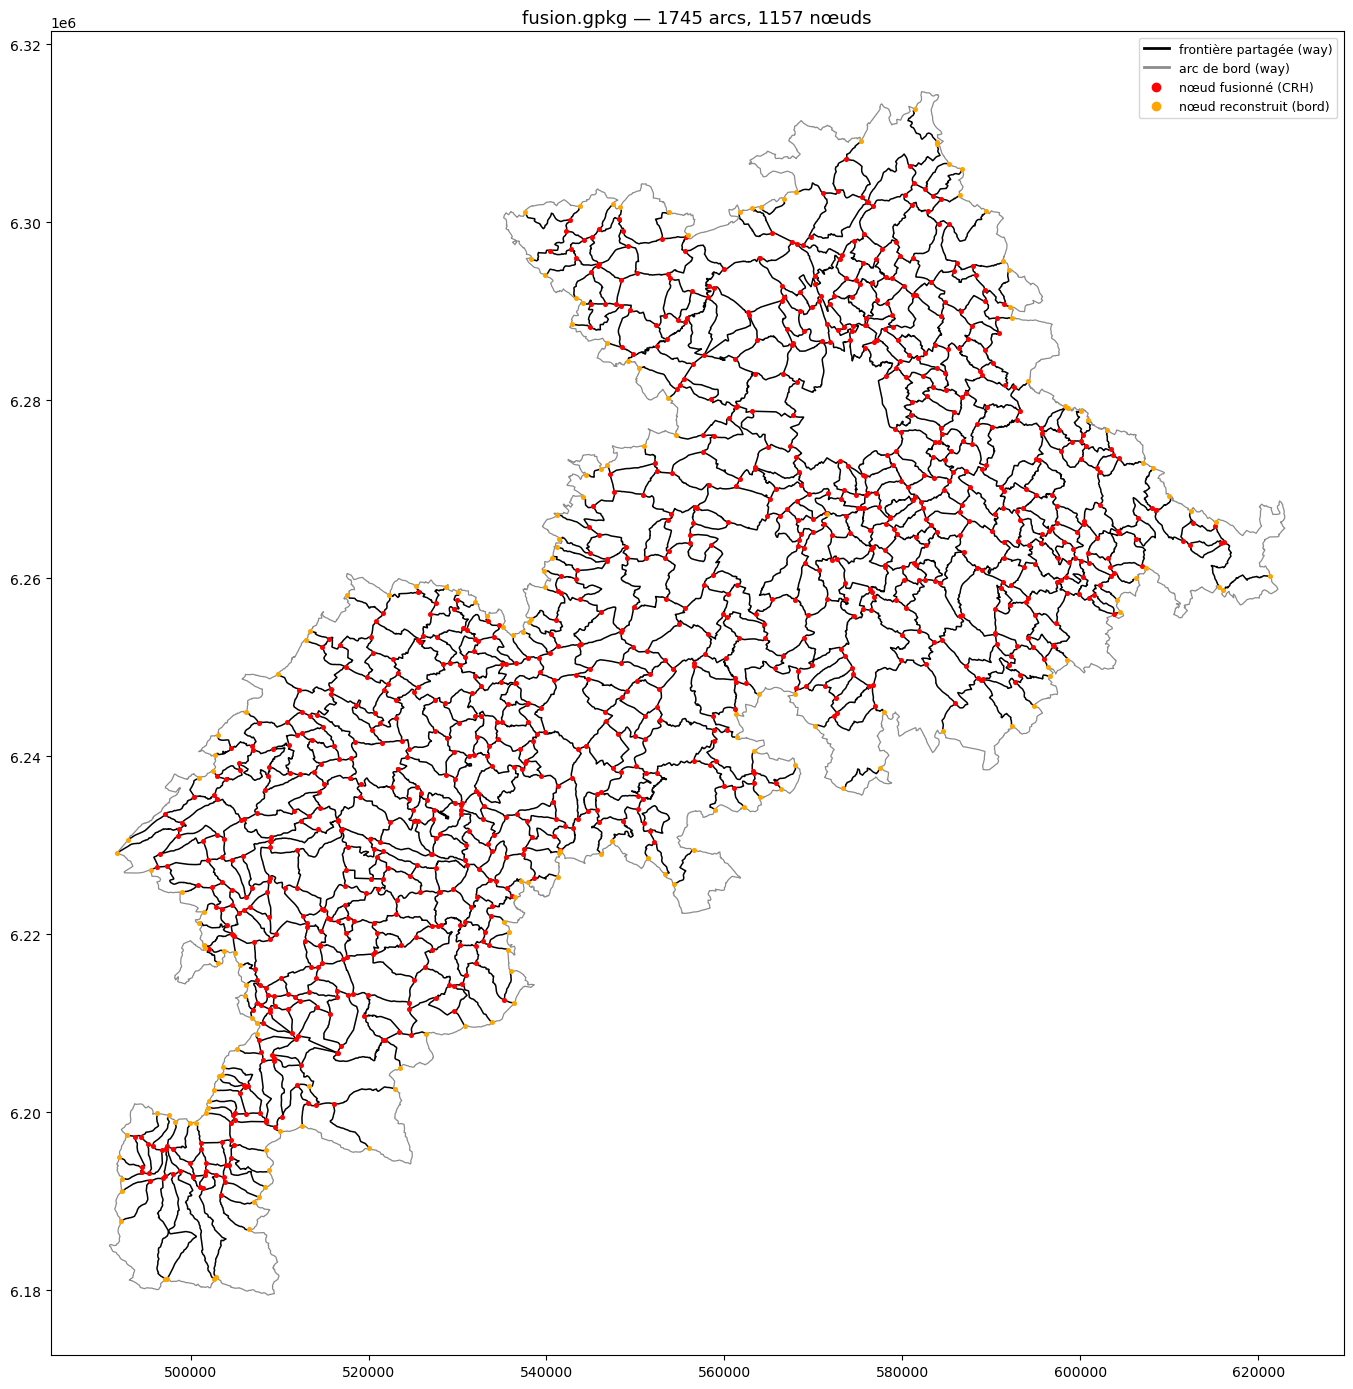

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

arcs   = gpd.read_file(f'{MATCHING_DIR}/fusion.gpkg', layer='arcs')
noeuds = gpd.read_file(f'{MATCHING_DIR}/fusion.gpkg', layer='noeuds')
print(noeuds['type'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(14, 14))
for geom in arcs[arcs['partage']].geometry:
    ax.plot(*geom.xy, color='black', lw=1.1)
for geom in arcs[~arcs['partage']].geometry:
    ax.plot(*geom.xy, color='0.55', lw=0.9)
sel = noeuds['type'] == 'fusionne'
noeuds[sel].plot(ax=ax, color='red', markersize=7, zorder=5)
noeuds[~sel].plot(ax=ax, color='orange', markersize=7, zorder=5)
ax.set_aspect('equal')
ax.set_title(f'fusion.gpkg — {len(arcs)} arcs, {len(noeuds)} nœuds', fontsize=13)
ax.legend(handles=[Line2D([0],[0],color='black',lw=2,label='frontière partagée (way)'),
                   Line2D([0],[0],color='0.55',lw=2,label='arc de bord (way)'),
                   Line2D([0],[0],marker='o',color='red',lw=0,label='nœud fusionné (CRH)'),
                   Line2D([0],[0],marker='o',color='orange',lw=0,label='nœud reconstruit (bord)')], fontsize=9)
plt.tight_layout(); plt.savefig(f'{MATCHING_DIR}/fusion_apercu.png', dpi=150, bbox_inches='tight'); plt.show()


## 12. QA topologique — invariants et anomalies

Après l'élagage, l'attendu est : nœuds FUSION = nœuds BD Topo (119), deg1 = 0, deg2 = 0, arcs parallèles = 0.

In [18]:
# Les suspects sont exportés dans fusion_qa.gpkg pour inspection QGIS.
from collections import Counter as _Counter
from shapely.geometry import Point as _Point, LineString as _LS

TOPO_DIR_QA   = r'C:/Users/rocrom/conversion_osm/04_topo_d031'
CLOSE_NODE_QA = 150.0     # deux nœuds à moins de 150 m = suspect

def _endpoints_deg(arcs_gdf, nd=2):
    deg = _Counter()
    for g in arcs_gdf.geometry:
        c = np.array(g.coords)
        deg[tuple(np.round(c[0], nd))] += 1
        deg[tuple(np.round(c[-1], nd))] += 1
    return deg

def _invariants(arcs_gdf, name):
    deg = _endpoints_deg(arcs_gdf)
    d1 = sum(1 for v in deg.values() if v == 1)
    d2 = sum(1 for v in deg.values() if v == 2)
    d3 = sum(1 for v in deg.values() if v >= 3)
    print(f'{name:>10} | arcs {len(arcs_gdf):4d} | nœuds {len(deg):4d} | '
          f'deg1 {d1:3d} | deg2 {d2:3d} | deg≥3 {d3:3d}')
    return deg

print('=== Invariants topologiques (arcs partagés + bord) ===')
srcs_qa = {}
for s in sorted(gpd.read_file(f'{MATCHING_DIR}/edges.gpkg')['source'].unique()):
    g = gpd.read_file(f'{TOPO_DIR_QA}/topo_{s}.gpkg', layer='arcs')
    srcs_qa[s] = _invariants(g, s)
fus = gpd.read_file(f'{MATCHING_DIR}/fusion.gpkg', layer='arcs')
deg_f = _invariants(fus, 'FUSION')

print('\nLecture : deg≥3 (jonctions) de FUSION doit ≈ celui de la source de référence ;')
print('deg2 doit être ~0 (chaque deg2 = un arc coupé sans jonction réelle) ;')
print('deg1 = extrémités de coupe de zone uniquement.')

# --- détecteur 1 : nœuds de degré 2 ---
deg2_pts = [k for k, v in deg_f.items() if v == 2]
if deg2_pts:
    gpd.GeoDataFrame({'geometry': [_Point(p) for p in deg2_pts]}, crs=CRS).to_file(
        f'{MATCHING_DIR}/fusion_qa.gpkg', layer='noeuds_degre2', driver='GPKG')
print(f'\nNœuds de degré 2 : {len(deg2_pts)}'
      + (' -> fusion_qa.gpkg / noeuds_degre2' if deg2_pts else ''))

# --- détecteur 2 : paires de nœuds proches ---
N = np.array(list(deg_f.keys()), float)
pairs = []
for i in range(len(N)):
    for j in range(i + 1, len(N)):
        d = float(np.hypot(*(N[i] - N[j])))
        if d <= CLOSE_NODE_QA:
            pairs.append((i, j, d))
if pairs:
    gpd.GeoDataFrame(
        {'dist_m': [round(d, 1) for _, _, d in pairs],
         'geometry': [_LS([N[i], N[j]]) for i, j, _ in pairs]}, crs=CRS).to_file(
        f'{MATCHING_DIR}/fusion_qa.gpkg', layer='noeuds_proches', driver='GPKG')
print(f'Paires de nœuds < {CLOSE_NODE_QA:.0f} m : {len(pairs)}'
      + (' -> fusion_qa.gpkg / noeuds_proches' if pairs else ''))

# --- détecteur 3 : arcs parallèles (mêmes deux extrémités) ---
seen, dup_idx = {}, []
for idx, g in zip(fus.index, fus.geometry):
    c = np.array(g.coords)
    key = tuple(sorted([tuple(np.round(c[0], 2)), tuple(np.round(c[-1], 2))]))
    if key in seen:
        dup_idx.extend([seen[key], idx])
    else:
        seen[key] = idx
dup_idx = sorted(set(dup_idx))
if dup_idx:
    fus.loc[dup_idx].to_file(f'{MATCHING_DIR}/fusion_qa.gpkg',
                             layer='arcs_paralleles', driver='GPKG')
    print(f'Arcs parallèles : {len(dup_idx)} -> fusion_qa.gpkg / arcs_paralleles')
    print(fus.loc[dup_idx, ['comm_a', 'comm_b', 'partage', 'sources', 'longueur']]
          .to_string())
else:
    print('Arcs parallèles : 0')


=== Invariants topologiques (arcs partagés + bord) ===
    bdtopo | arcs 1743 | nœuds 1158 | deg1   0 | deg2   0 | deg≥3 1158
  cadastre | arcs 1868 | nœuds 1233 | deg1   0 | deg2   4 | deg≥3 1229
    geofla | arcs 1743 | nœuds 1157 | deg1   0 | deg2   0 | deg≥3 1157
    FUSION | arcs 1745 | nœuds 1157 | deg1   0 | deg2   0 | deg≥3 1157

Lecture : deg≥3 (jonctions) de FUSION doit ≈ celui de la source de référence ;
deg2 doit être ~0 (chaque deg2 = un arc coupé sans jonction réelle) ;
deg1 = extrémités de coupe de zone uniquement.

Nœuds de degré 2 : 0
Paires de nœuds < 150 m : 18 -> fusion_qa.gpkg / noeuds_proches
Arcs parallèles : 18 -> fusion_qa.gpkg / arcs_paralleles
     comm_a comm_b  partage                 sources      longueur
29    31371  31463     True  bdtopo,cadastre,geofla   4431.494913
31    31463  31478     True  bdtopo,cadastre,geofla   5228.466759
522   31409  31429     True           bdtopo,geofla   3702.895440
541   31365  31375     True         bdtopo,cadastre   586

### 12b. Non-régression : arcs pendants

In [19]:
# --- détecteur 4 : arcs PENDANTS (extrémité de degré 1) ---
# Après l'élagage de la section 8e, ce détecteur doit rendre 0 : il sert de
# non-régression. S'il trouve des arcs, l'élagage n'a pas été appliqué (relancer main).
deg1_pts = {k for k, v in deg_f.items() if v == 1}
pend_idx = []
for idx, g in zip(fus.index, fus.geometry):
    c = np.array(g.coords)
    if tuple(np.round(c[0], 2)) in deg1_pts or tuple(np.round(c[-1], 2)) in deg1_pts:
        pend_idx.append(idx)
print(f'Arcs pendants restants : {len(pend_idx)} (attendu : 0)')
if pend_idx:
    cols = ['comm_a', 'comm_b', 'partage', 'n_sources', 'sources', 'longueur']
    print(fus.loc[pend_idx, cols].to_string())
    fus.loc[pend_idx].to_file(f'{MATCHING_DIR}/fusion_qa.gpkg',
                              layer='arcs_pendants', driver='GPKG')


Arcs pendants restants : 0 (attendu : 0)


### 12c. Diagnostic : recouvrements toutes étiquettes confondues

À lancer après `main()`. Détermine si les doubles restants sont de **même paire** (bug de la dédup) ou de **paires différentes** (désaccord d'étiquettes entre sources — angle mort du critère d'identité).

In [20]:
# --- détecteur 5 : recouvrements forts TOUTES ÉTIQUETTES CONFONDUES ---
# Tranche l'origine des doubles restants : même paire (la dédup aurait dû agir)
# ou paires différentes (désaccord d'étiquettes entre sources -> angle mort du
# critère d'identité). À lancer sur le fusion.gpkg produit par ce notebook.
from shapely import STRtree as _STRtree

_arcs = gpd.read_file(f'{MATCHING_DIR}/fusion.gpkg', layer='arcs').reset_index(drop=True)
_TOL, _SEUIL = 50.0, 0.8
_geoms = list(_arcs.geometry)
_tree = _STRtree(_geoms)

def _pair(k):
    return tuple(sorted([str(_arcs.loc[k, 'comm_a']), str(_arcs.loc[k, 'comm_b'])]))

_rows = []
for i, g in enumerate(_geoms):
    for j in _tree.query(g.buffer(_TOL)):
        j = int(j)
        if j <= i:
            continue
        gi, gj = _geoms[i], _geoms[j]
        shorter, longer = (gi, gj) if gi.length <= gj.length else (gj, gi)
        ov = (shorter.intersection(longer.buffer(_TOL)).length
              / max(shorter.length, 1e-9))
        if ov > _SEUIL:
            _rows.append({'i': i, 'j': j, 'recouvrement': round(ov, 2),
                          'meme_paire': _pair(i) == _pair(j),
                          'paire_i': '-'.join(_pair(i)), 'paire_j': '-'.join(_pair(j)),
                          'sources_i': _arcs.loc[i, 'sources'],
                          'sources_j': _arcs.loc[j, 'sources'],
                          'long_i': round(float(_arcs.loc[i, 'longueur'])),
                          'long_j': round(float(_arcs.loc[j, 'longueur']))})

print(f'Recouvrements forts (> {_SEUIL:.0%} à {_TOL:.0f} m) : {len(_rows)}')
if _rows:
    df = pd.DataFrame(_rows)
    print(f"  dont MÊME paire       : {int(df['meme_paire'].sum())}  "
          f"(-> la dédup par paire aurait dû agir : bug à corriger)")
    print(f"  dont paires DIFFÉRENTES: {int((~df['meme_paire']).sum())}  "
          f"(-> désaccord d'étiquettes entre sources : angle mort du critère)")
    print(df.head(20).to_string())
    idx = sorted({r['i'] for r in _rows} | {r['j'] for r in _rows})
    _arcs.loc[idx].drop(columns=['poids', 'exclus'], errors='ignore').to_file(
        f'{MATCHING_DIR}/fusion_qa.gpkg', layer='recouvrements_restants', driver='GPKG')
    print('  -> fusion_qa.gpkg / recouvrements_restants (pour inspection QGIS)')


Recouvrements forts (> 80% à 50 m) : 26
  dont MÊME paire       : 0  (-> la dédup par paire aurait dû agir : bug à corriger)
  dont paires DIFFÉRENTES: 26  (-> désaccord d'étiquettes entre sources : angle mort du critère)
      i     j  recouvrement  meme_paire      paire_i      paire_j               sources_i               sources_j  long_i  long_j
0    36  1743          1.00       False  31177-31471  31085-31177         bdtopo,cadastre                cadastre    3622      19
1   207   335          1.00       False  31183-31296  31050-31183  bdtopo,cadastre,geofla           bdtopo,geofla    1654      39
2   257   473          1.00       False  31026-31102  31026-31329         bdtopo,cadastre           bdtopo,geofla    4200      49
3   262   725          1.00       False  31122-31309  31119-31309  bdtopo,cadastre,geofla  bdtopo,cadastre,geofla    1866      36
4   335  1430          1.00       False  31050-31183  31183-31372           bdtopo,geofla                  bdtopo      39    461